<a href="https://colab.research.google.com/github/i-ganza007/Match_Backend/blob/main/Siasmese_TWIN_TEST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ianganza_livestock_images_path = kagglehub.dataset_download('ianganza/livestock-images')

print('Data source import complete.')


In [ ]:
import os
import random
import numpy as np
from PIL import Image, ImageEnhance
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, BatchNormalization, GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ModelCheckpoint

2026-03-30 21:00:44.887097: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774904445.340994      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774904445.453019      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774904446.554199      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774904446.554237      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774904446.554240      55 computation_placer.cc:177] computation placer alr

In [ ]:
@tf.keras.utils.register_keras_serializable()
class ContrastiveLoss(tf.keras.losses.Loss):
    def __init__(self, margin=1.0, **kwargs):
        super().__init__(**kwargs)
        self.margin = margin

    def call(self, y_true, y_pred):
        square_pred = tf.square(y_pred)
        margin_square = tf.square(tf.maximum(self.margin - y_pred, 0))
        return tf.reduce_mean(y_true * square_pred + (1 - y_true) * margin_square)

In [ ]:
@tf.keras.utils.register_keras_serializable()
class SpatialChannelAttention(tf.keras.layers.Layer):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = tf.keras.layers.GlobalAveragePooling2D(keepdims=True)
        self.max_pool = tf.keras.layers.GlobalMaxPooling2D(keepdims=True)
        self.fc = tf.keras.Sequential([
            tf.keras.layers.Dense(in_channels // reduction, use_bias=False),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Dense(in_channels, use_bias=False)
        ])
        self.conv_spatial = tf.keras.layers.Conv2D(1, kernel_size=7, padding='same', use_bias=False)
        self.sigmoid = tf.keras.layers.Activation('sigmoid')

    def call(self, x):
        # Channel Attention
        avg_out = tf.squeeze(self.avg_pool(x), [1, 2])
        avg_out = tf.expand_dims(tf.expand_dims(self.fc(avg_out), 1), 1)
        max_out = tf.squeeze(self.max_pool(x), [1, 2])
        max_out = tf.expand_dims(tf.expand_dims(self.fc(max_out), 1), 1)
        channel_att = self.sigmoid(avg_out + max_out)
        x = x * channel_att

        # Spatial Attention
        avg_mask = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_mask = tf.reduce_max(x, axis=-1, keepdims=True)
        spatial_in = tf.concat([avg_mask, max_mask], axis=-1)
        spatial_att = self.sigmoid(self.conv_spatial(spatial_in))
        return x * spatial_att

In [ ]:
@tf.keras.utils.register_keras_serializable()
class RawCNNSiamese(tf.keras.Model):
    def __init__(self, embedding_dim=512, margin=1.0):
        super().__init__()
        self.features = tf.keras.Sequential([
            Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
            BatchNormalization(), Conv2D(32, (3, 3), activation='relu', padding='same'), BatchNormalization(),
            MaxPooling2D((2, 2)), Dropout(0.25),

            Conv2D(64, (3, 3), activation='relu', padding='same'),
            BatchNormalization(), Conv2D(64, (3, 3), activation='relu', padding='same'), BatchNormalization(),
            MaxPooling2D((2, 2)), Dropout(0.25),

            Conv2D(128, (3, 3), activation='relu', padding='same'),
            BatchNormalization(), Conv2D(128, (3, 3), activation='relu', padding='same'), BatchNormalization(),
            MaxPooling2D((2, 2)), Dropout(0.3),

            Conv2D(256, (3, 3), activation='relu', padding='same'),
            BatchNormalization(), Conv2D(256, (3, 3), activation='relu', padding='same'), BatchNormalization(),
            MaxPooling2D((2, 2)), Dropout(0.4),
        ])
        self.attention = SpatialChannelAttention(256)
        self.pool = GlobalAveragePooling2D()
        self.fc = tf.keras.Sequential([
            Dense(512), BatchNormalization(), tf.keras.layers.ReLU(), Dropout(0.4), Dense(embedding_dim)
        ])
        self.margin = margin

    def forward_once(self, x, training=False):
        x = self.features(x, training=training)
        x = self.attention(x)
        x = self.pool(x)
        x = self.fc(x)
        return tf.nn.l2_normalize(x, axis=-1)

    def call(self, inputs, training=False):
        img1, img2 = inputs
        feat1 = self.forward_once(img1, training=training)
        feat2 = self.forward_once(img2, training=training)
        return tf.norm(feat1 - feat2, axis=-1)

In [ ]:
dataset_path = '/kaggle/input/datasets/ianganza/livestock-images/Data'

breeds = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
print(f'Total breeds found: {len(breeds)}')

breed_images = {}
for breed in breeds:
    breed_dir = os.path.join(dataset_path, breed)
    images = [os.path.join(breed_dir, img) for img in os.listdir(breed_dir)
              if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    breed_images[breed] = images

print(f"Loaded {len(breed_images)} breeds with images.")

Total breeds found: 14
Loaded 14 breeds with images.


In [ ]:
def generate_balanced_pairs(breed_dict, pairs_per_class=200):
    pairs, labels = [], []
    all_breeds = list(breed_dict.keys())
    for breed in all_breeds:
        images = breed_dict[breed]
        if len(images) < 2: continue
        # Positive pairs
        for _ in range(pairs_per_class // 2):
            img1, img2 = random.sample(images, 2)
            pairs.append((img1, img2))
            labels.append(1)
        # Negative pairs
        other_breeds = [b for b in all_breeds if b != breed]
        for _ in range(pairs_per_class // 2):
            img1 = random.choice(images)
            other = random.choice(other_breeds)
            img2 = random.choice(breed_dict[other])
            pairs.append((img1, img2))
            labels.append(0)
    return np.array(pairs, dtype=object), np.array(labels)
X, y = generate_balanced_pairs(breed_images, pairs_per_class=200)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f'Total pairs: {len(X)} | Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Total pairs: 2800 | Train: 2240 | Val: 280 | Test: 280


In [ ]:
class SiamesePairGenerator(tf.keras.utils.Sequence):
    def __init__(self, breed_dict, batch_size=16, training=True):
        self.batch_size = batch_size
        self.breed_dict = breed_dict
        self.breeds = [b for b in breed_dict.keys() if len(breed_dict[b]) >= 2]
        self.training = training

    def __len__(self):
        return 2000 // self.batch_size

    def __getitem__(self, idx):
        img1_batch = np.zeros((self.batch_size, 224, 224, 3), dtype=np.float32)
        img2_batch = np.zeros((self.batch_size, 224, 224, 3), dtype=np.float32)
        labels = np.zeros((self.batch_size,), dtype=np.float32)

        for i in range(self.batch_size):
            anchor_breed = random.choice(self.breeds)
            img_paths = self.breed_dict[anchor_breed]
            if random.random() < 0.5 and len(img_paths) >= 2:
                p1, p2 = random.sample(img_paths, 2)
                labels[i] = 1.0
            else:
                p1 = random.choice(img_paths)
                other = random.choice([b for b in self.breeds if b != anchor_breed])
                p2 = random.choice(self.breed_dict[other])
                labels[i] = 0.0

            img1_batch[i] = self.load_and_preprocess(p1, self.training)
            img2_batch[i] = self.load_and_preprocess(p2, self.training)
        return (img1_batch, img2_batch), labels

    def load_and_preprocess(self, path, training):
        img = Image.open(path).convert('RGB')
        if training:
            img = img.resize((256, 256), Image.LANCZOS)
            left = random.randint(0, 256 - 224)
            top = random.randint(0, 256 - 224)
            img = img.crop((left, top, left + 224, top + 224))
            if random.random() > 0.5:
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
            factors = [random.uniform(0.9, 1.1) for _ in range(3)]
            img = ImageEnhance.Brightness(img).enhance(factors[0])
            img = ImageEnhance.Contrast(img).enhance(factors[1])
            img = ImageEnhance.Color(img).enhance(factors[2])
        else:
            img = img.resize((224, 224), Image.LANCZOS)
        return np.array(img).astype(np.float32) / 255.0


train_generator = SiamesePairGenerator(breed_images, batch_size=16, training=True)
val_generator   = SiamesePairGenerator(breed_images, batch_size=16, training=False)

In [ ]:
model = RawCNNSiamese(embedding_dim=512, margin=1.0)

model.compile(
    optimizer=AdamW(learning_rate=1e-4, weight_decay=1e-4),
    loss=ContrastiveLoss(margin=1.0)
)

print("🚀 Starting Raw CNN Siamese (Contrastive / Twin Loss) Training...")

callbacks = [ModelCheckpoint('best_rawcnn_contrastive.keras',
                             monitor='loss', save_best_only=True, mode='min', verbose=1)]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=callbacks
)

print("Training finished.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1774904791.954788      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774904791.960777      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


🚀 Starting Raw CNN Siamese (Contrastive / Twin Loss) Training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


I0000 00:00:1774904808.132261     135 service.cc:152] XLA service 0x7ee19000acb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774904808.132303     135 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774904808.132310     135 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774904810.070915     135 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-30 21:06:56.223750: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-30 21:06:56.374854: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-30 21:06:57.904470: E external/local_xl

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.5437
Epoch 1: loss improved from inf to 0.41081, saving model to best_rawcnn_contrastive.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - loss: 0.5426 - val_loss: 0.4879
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.2542
Epoch 2: loss improved from 0.41081 to 0.25430, saving model to best_rawcnn_contrastive.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 275s 2s/step - loss: 0.2542 - val_loss: 0.4134
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.2535
Epoch 3: loss improved from 0.25430 to 0.25185, saving model to best_rawcnn_contrastive.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - loss: 0.2535 - val_loss: 0.3794
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.2500
Epoch 4: loss improved from 0.25185 to 0.24997, saving model to best_rawcnn_contrastive.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - loss: 0.2500 - val_loss: 0.3525
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.2502
Epoch

Calculating TTA distances on test set...
Processed 50/280 pairs...
Processed 100/280 pairs...
Processed 150/280 pairs...
Processed 200/280 pairs...
Processed 250/280 pairs...


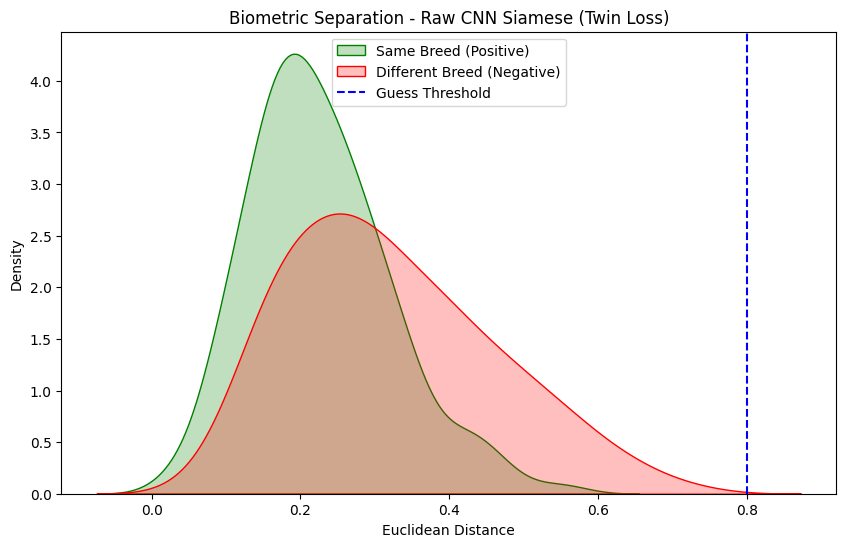


FINAL PERFORMANCE REPORT - RAW CNN SIAMESE (TWIN LOSS)
Optimal Threshold : 0.3591
Accuracy          : 0.6429
Precision         : 0.5917
Recall            : 0.9214
F1-Score          : 0.7207
Positive pairs    : 140
Negative pairs    : 140


In [ ]:
# model = tf.keras.models.load_model(
#     'best_rawcnn_contrastive.keras',
#     custom_objects={
#         'ContrastiveLoss': ContrastiveLoss,
#         'SpatialChannelAttention': SpatialChannelAttention,
#         'RawCNNSiamese': RawCNNSiamese
#     }
# )
# print("✅ Best model loaded successfully!")


# ====================== 7. TTA + FINAL METRICS ======================
def load_and_preprocess_pil(img_pil, training):
    img = img_pil
    if training:
        img = img.resize((256, 256), Image.LANCZOS)
        left = random.randint(0, 256 - 224)
        top = random.randint(0, 256 - 224)
        img = img.crop((left, top, left + 224, top + 224))
        if random.random() > 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
        factors = [random.uniform(0.9, 1.1) for _ in range(3)]
        img = ImageEnhance.Brightness(img).enhance(factors[0])
        img = ImageEnhance.Contrast(img).enhance(factors[1])
        img = ImageEnhance.Color(img).enhance(factors[2])
    else:
        img = img.resize((224, 224), Image.LANCZOS)
    return np.array(img).astype(np.float32) / 255.0


def get_tta_distance(path1, path2, model, num_aug=5):
    path1 = str(path1).strip("[]'\"\n ")
    path2 = str(path2).strip("[]'\"\n ")
    img1_pil = Image.open(path1).convert('RGB')
    img2_pil = Image.open(path2).convert('RGB')
    dists = []
    for _ in range(num_aug):
        t1 = load_and_preprocess_pil(img1_pil, training=True)
        t2 = load_and_preprocess_pil(img2_pil, training=True)
        t1 = np.expand_dims(t1, 0)
        t2 = np.expand_dims(t2, 0)
        feat1 = model.forward_once(t1, training=False)
        feat2 = model.forward_once(t2, training=False)
        dist = tf.norm(feat1 - feat2).numpy()
        dists.append(dist)
    return float(np.mean(dists))


# Compute TTA distances
print("Calculating TTA distances on test set...")
tta_distances = []
for i, pair in enumerate(X_test):
    d = get_tta_distance(pair[0], pair[1], model, num_aug=5)
    tta_distances.append(d)
    if (i + 1) % 50 == 0:
        print(f"Processed {i+1}/{len(X_test)} pairs...")
tta_distances = np.array(tta_distances)

# Plot separation
pos = tta_distances[y_test == 1]
neg = tta_distances[y_test == 0]
plt.figure(figsize=(10, 6))
sns.kdeplot(pos, label="Same Breed (Positive)", fill=True, color='green')
sns.kdeplot(neg, label="Different Breed (Negative)", fill=True, color='red')
plt.axvline(x=0.8, color='blue', linestyle='--', label='Guess Threshold')
plt.title("Biometric Separation - Raw CNN Siamese (Twin Loss)")
plt.xlabel("Euclidean Distance")
plt.ylabel("Density")
plt.legend()
plt.show()

# Find best threshold & metrics
best_f1, optimal_t = 0, 0
for t in np.linspace(tta_distances.min(), tta_distances.max(), 200):
    preds = (tta_distances < t).astype(int)
    current_f1 = f1_score(y_test, preds)
    if current_f1 > best_f1:
        best_f1 = current_f1
        optimal_t = t

final_preds = (tta_distances < optimal_t).astype(int)

print("\n" + "="*60)
print("FINAL PERFORMANCE REPORT - RAW CNN SIAMESE (TWIN LOSS)")
print("="*60)
print(f"Optimal Threshold : {optimal_t:.4f}")
print(f"Accuracy          : {accuracy_score(y_test, final_preds):.4f}")
print(f"Precision         : {precision_score(y_test, final_preds):.4f}")
print(f"Recall            : {recall_score(y_test, final_preds):.4f}")
print(f"F1-Score          : {f1_score(y_test, final_preds):.4f}")
print(f"Positive pairs    : {sum(y_test)}")
print(f"Negative pairs    : {len(y_test) - sum(y_test)}")
print("="*60)